# Lab: Supervised Machine Learning for Time Series (Student Version)

Based on Lecture 3, this lab will guide you through the paradigm shift from classical statistical models to supervised machine learning models for time series forecasting.

**Learning Objectives:**
1. Transform a raw time series into a tabular format.
2. Engineer advanced features (Time Embeddings, Lags, Rolling Windows).
3. Perform chronological validation to prevent target leakage.
4. Train a tree-based model (XGBoost/Random Forest) and observe the extrapolation problem.
5. Implement a Direct Multi-Step Forecasting strategy.

**Dataset:** BTC-USD 1-Minute Data

In [63]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")
# Download the BTC dataset
path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data", output_dir="btc_data")
print("Path to dataset ready at:", path)
data_path = path + "/btc_1m.csv" # Note: you may need to adjust the exact filename based on the extracted contents

Path to dataset ready at: btc_data


## Task 1: Load and Resample the Data
The 1-minute dataset is massive. To make our feature engineering and model training efficient, we need to resample this data to a **Daily** frequency.

1. Load the CSV using pandas.
2. Convert the timestamp column to a `datetime` object and set it as the index.
3. Resample the data to daily frequency (`'D'`). Use `.last()` for the 'Close' price, and `.sum()` for 'Volume'. For this lab, we will primarily focus on predicting the daily **Close** price.

In [64]:
# YOUR CODE HERE
data = pd.read_csv("btc_data/BTCUSD_1m_Binance.csv")
data.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183,2017-08-17 04:00:59.999,7564.906851,3.0,0.075183,320.390851,0.0
1,2017-08-17 04:01:00,4261.48,4261.48,4261.48,4261.48,0.000000,2017-08-17 04:01:59.999,0.000000,0.0,0.000000,0.000000,0.0
2,2017-08-17 04:02:00,4280.56,4280.56,4280.56,4280.56,0.261074,2017-08-17 04:02:59.999,1117.542921,2.0,0.261074,1117.542921,0.0
3,2017-08-17 04:03:00,4261.48,4261.48,4261.48,4261.48,0.012008,2017-08-17 04:03:59.999,51.171852,3.0,0.012008,51.171852,0.0
4,2017-08-17 04:04:00,4261.48,4261.48,4261.48,4261.48,0.140796,2017-08-17 04:04:59.999,599.999338,1.0,0.140796,599.999338,0.0


In [65]:
data["timestamp"] = pd.to_datetime(data["Open time"], unit="ms")
data.set_index("timestamp", inplace=True)
data_daily = data.resample('D').agg({
    'Close': 'last', 
    'Volume': 'sum'
})
data_daily.head()

,Close,Volume
timestamp,,
2017-08-17,4285.08,795.150377
2017-08-18,4108.37,1199.888264
2017-08-19,4139.98,381.309763
2017-08-20,4086.29,467.083022
2017-08-21,4016.00,691.743060


## Task 2: Advanced Feature Engineering (Time Embeddings)
Machine learning models don't inherently understand dates. We must extract temporal features so the model can learn seasonality (e.g., "Is it the weekend?", "What month is it?").

Create the following columns in `df_daily`:
- `day_of_week`
- `month`
- `day_of_year`
- `is_weekend` (1 if Saturday/Sunday, 0 otherwise)

In [66]:
# YOUR CODE HERE
data_daily["day_of_week"] = data_daily.index.dayofweek
data_daily["month"] = data_daily.index.month
data_daily["year"] = data_daily.index.year
data_daily["is_weekend"] = data_daily.index.dayofweek.isin([5, 6]).astype(int)
data_daily.head()

,Close,Volume,day_of_week,month,year,is_weekend
timestamp,,,,,,
2017-08-17,4285.08,795.150377,3,8,2017,0
2017-08-18,4108.37,1199.888264,4,8,2017,0
2017-08-19,4139.98,381.309763,5,8,2017,1
2017-08-20,4086.29,467.083022,6,8,2017,1
2017-08-21,4016.00,691.743060,0,8,2017,0


## Task 3: Advanced Feature Engineering (Lags and Rolling Windows)
To capture autoregressive patterns, we need to give the model historical context for the current row. 

Create the following features based on the `Close` price:
1. **Lags**: `lag_1`, `lag_3`, `lag_7` (Values from 1, 3, and 7 days ago).
2. **Rolling Windows**: `rolling_mean_7`, `rolling_std_7` (7-day moving average and standard deviation).

*Hint: Use `df.shift()` and `df.rolling()`.*
*Crucial step: Drop any rows containing NaN values generated by shifting!*

In [67]:
# YOUR CODE HERE
lags = [1, 3, 7]
mean_std_window = 7

for lag in lags:
    data_daily[f"lag_{lag}"] = data_daily["Close"].shift(lag)
data_daily["roll_mean_7"] = data_daily["Close"].rolling(window=mean_std_window).mean()
data_daily["roll_std_7"] = data_daily["Close"].rolling(window=mean_std_window).std()
data_daily.dropna(inplace=True)
data_daily.head()

,Close,Volume,day_of_week,month,year,is_weekend,lag_1,lag_3,lag_7,roll_mean_7,roll_std_7
timestamp,,,,,,,,,,,
2017-08-24,4316.01,787.418753,3,8,2017,0,4114.01,4016.00,4285.08,4117.237143,97.714881
2017-08-25,4280.68,573.612740,4,8,2017,0,4316.01,4040.00,4108.37,4141.852857,115.240759
2017-08-26,4337.44,228.108068,5,8,2017,1,4280.68,4114.01,4139.98,4170.061429,136.847454
2017-08-27,4310.01,350.692585,6,8,2017,1,4337.44,4316.01,4086.29,4202.021429,140.107823
2017-08-28,4386.69,603.841616,0,8,2017,0,4310.01,4280.68,4016.00,4254.977143,127.573227


## Task 4: Chronological Train/Test Split
**Danger of Target Leakage**: In time series, we cannot use random `train_test_split`. We must split chronologically to avoid using future data to predict the past.

1. Define your features (`X`) and your target variable (`y`, which is `Close`).
2. Split the data chronologically: the first 80% of rows for training, the last 20% for testing.

In [68]:
# YOUR CODE HERE
train_size = int(len(data_daily) * 0.8)
train_data = data_daily.iloc[:train_size] # 0 --> 80% for training
test_data = data_daily.iloc[train_size:] # 80% --> 100% for testing
print(f"train_data.shape: {train_data.shape}, test_data.shape: {test_data.shape}")
print(f"last element in train_data: {train_data.index[-1]}, first element in test_data: {test_data.index[0]}")

train_data.shape: (2376, 11), test_data.shape: (595, 11)
last element in train_data: 2024-02-24 00:00:00, first element in test_data: 2024-02-25 00:00:00


## Task 5: Train a Tree-Based Model (XGBoost or Random Forest)
Now that the data is tabular, train a supervised machine learning model.

1. Initialize an `XGBRegressor` or `RandomForestRegressor`.
2. Fit the model on `X_train` and `y_train`.
3. Make predictions on `X_test`.

In [69]:
# YOUR CODE HERE
from sklearn.metrics import root_mean_squared_error

features = [col for col in train_data.columns if col != "Close"]
target = "Close"

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    eval_metric='rmse'
)

xgb_model.fit(
    train_data[features], 
    train_data[target],
    eval_set=[(train_data[features], train_data[target]), 
              (test_data[features], test_data[target])],
    verbose=False
)
results = xgb_model.evals_result()
train_rmse = results['validation_0']['rmse']
test_rmse = results['validation_1']['rmse']

model_predictions_test_data = xgb_model.predict(test_data[features])

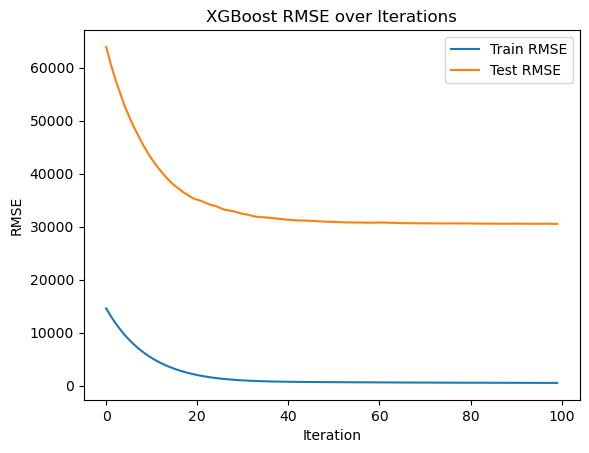

In [71]:
plt.plot(train_rmse, label='Train RMSE')
plt.plot(test_rmse, label='Test RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('XGBoost RMSE over Iterations')
plt.legend()
plt.show()

## Task 6: Evaluation & The Extrapolation Problem
Tree-based models are powerful but suffer from the **Extrapolation Problem**—they cannot predict values outside the range of their training data. 

1. Calculate the Root Mean Squared Error (RMSE).
2. Plot the Actual `y_test` values vs. the Predicted values.
3. **Reflection**: Look at the plot. Did the model struggle to predict newly established high or low price trends that weren't present in the training data? (Add your thoughts in a comment or text cell).

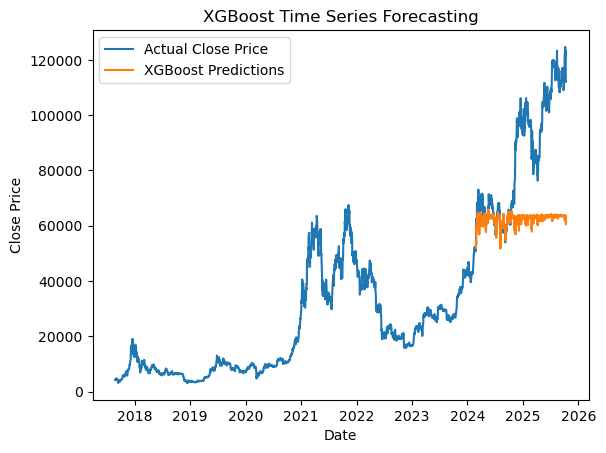

In [72]:
# YOUR CODE HERE
plt.plot(data_daily.index, data_daily["Close"], label='Actual Close Price')
plt.plot(test_data.index, model_predictions_test_data, label='XGBoost Predictions')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('XGBoost Time Series Forecasting')
plt.legend()
plt.show()

## My Thought Proccess:
 * model had a cap ceiling that couldnt go more than it (extrapolation)
 * applying differencing might help model learn better, by changing data from non stationary to stationary
 * to apply differnecing i have to do it before lag and rolling window

In [73]:
data_daily.head()

,Close,Volume,day_of_week,month,year,is_weekend,lag_1,lag_3,lag_7,roll_mean_7,roll_std_7
timestamp,,,,,,,,,,,
2017-08-24,4316.01,787.418753,3,8,2017,0,4114.01,4016.00,4285.08,4117.237143,97.714881
2017-08-25,4280.68,573.612740,4,8,2017,0,4316.01,4040.00,4108.37,4141.852857,115.240759
2017-08-26,4337.44,228.108068,5,8,2017,1,4280.68,4114.01,4139.98,4170.061429,136.847454
2017-08-27,4310.01,350.692585,6,8,2017,1,4337.44,4316.01,4086.29,4202.021429,140.107823
2017-08-28,4386.69,603.841616,0,8,2017,0,4310.01,4280.68,4016.00,4254.977143,127.573227


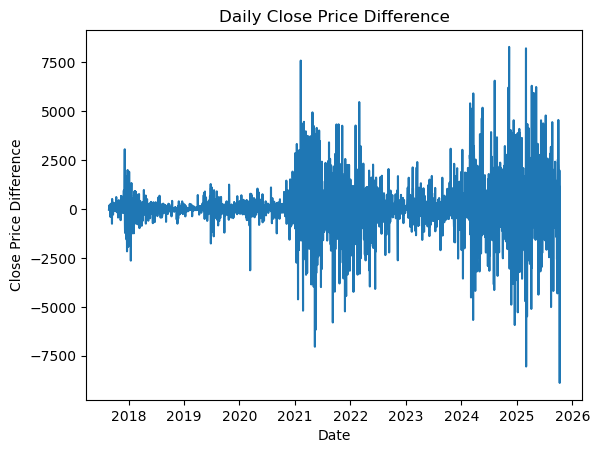

In [74]:
data_daily["Close_diff"] = data_daily["Close"].diff()
plt.plot(data_daily.index, data_daily["Close_diff"], label='Close Price Difference')
plt.xlabel('Date')
plt.ylabel('Close Price Difference')
plt.title('Daily Close Price Difference')
plt.show();

In [75]:
lags = [1, 3, 7]
mean_std_window = 7

for lag in lags:
    data_daily[f"diff_lag_{lag}"] = data_daily["Close_diff"].shift(lag)
data_daily["diff_roll_mean_7"] = data_daily["Close_diff"].rolling(window=mean_std_window).mean()
data_daily["diff_roll_std_7"] = data_daily["Close_diff"].rolling(window=mean_std_window).std()
data_daily.dropna(inplace=True)
data_daily.head()

,Close,Volume,day_of_week,month,year,is_weekend,lag_1,lag_3,lag_7,roll_mean_7,roll_std_7,Close_diff,diff_lag_1,diff_lag_3,diff_lag_7,diff_roll_mean_7,diff_roll_std_7
timestamp,,,,,,,,,,,,,,,,,
2017-09-01,4834.91,560.666366,4,9,2017,0,4724.89,4587.48,4280.68,4533.794286,200.333108,110.02,169.75,200.79,-35.33,79.175714,89.679365
2017-09-02,4472.14,929.148595,5,9,2017,1,4834.91,4555.14,4337.44,4553.037143,184.144127,-362.77,110.02,-32.34,56.76,19.242857,190.579926
2017-09-03,4509.08,691.216198,6,9,2017,1,4472.14,4724.89,4310.01,4581.475714,153.113862,36.94,-362.77,169.75,-27.43,28.438571,189.502487
2017-09-04,4100.11,1394.644614,0,9,2017,0,4509.08,4834.91,4386.69,4540.535714,231.913065,-408.97,36.94,110.02,76.68,-40.940000,248.586831
2017-09-05,4366.47,1228.938157,1,9,2017,0,4100.11,4472.14,4587.48,4508.962857,239.380871,266.36,-408.97,-362.77,200.79,-31.572857,260.178839


In [76]:
train_size = int(len(data_daily) * 0.8)
train_data = data_daily.iloc[:train_size]
test_data = data_daily.iloc[train_size:]
features = [col for col in train_data.columns if col not in ["Close", "Close_diff"]]
target = "Close_diff"

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric='rmse')
xgb_model.fit(
    train_data[features],
    train_data[target], 
    eval_set=[
        (train_data[features], train_data[target]),
        (test_data[features], test_data[target])],
    verbose=False)
xgb_predictions_diff = xgb_model.predict(test_data[features])

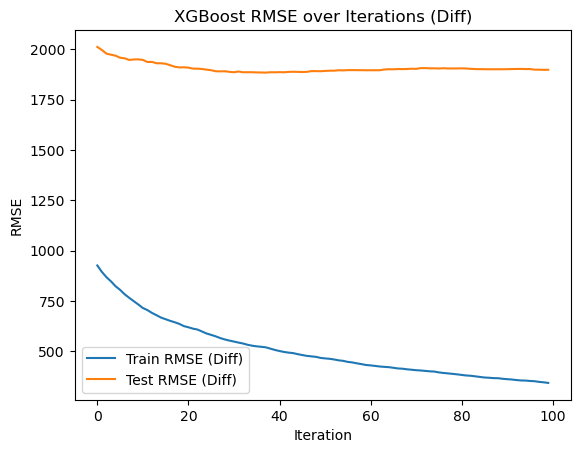

In [77]:
results_diff = xgb_model.evals_result()
train_rmse = results_diff['validation_0']['rmse']
test_rmse = results_diff['validation_1']['rmse']
plt.plot(train_rmse, label='Train RMSE (Diff)')
plt.plot(test_rmse, label='Test RMSE (Diff)')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('XGBoost RMSE over Iterations (Diff)')
plt.legend()
plt.show()

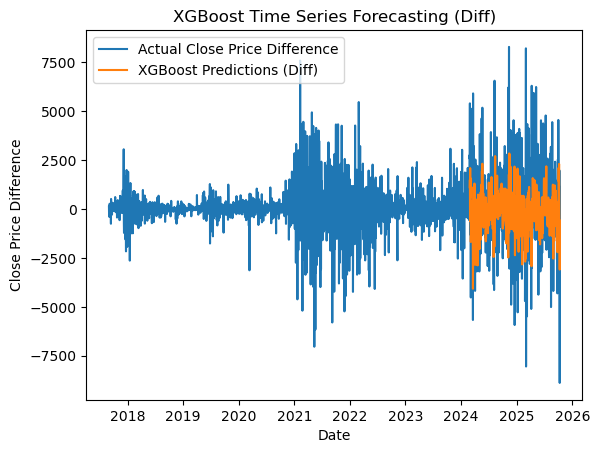

In [78]:
plt.plot(data_daily.index, data_daily["Close_diff"], label='Actual Close Price Difference')
plt.plot(test_data.index, xgb_predictions_diff, label='XGBoost Predictions (Diff)')
plt.xlabel('Date')
plt.ylabel('Close Price Difference')
plt.title('XGBoost Time Series Forecasting (Diff)')
plt.legend()
plt.show()

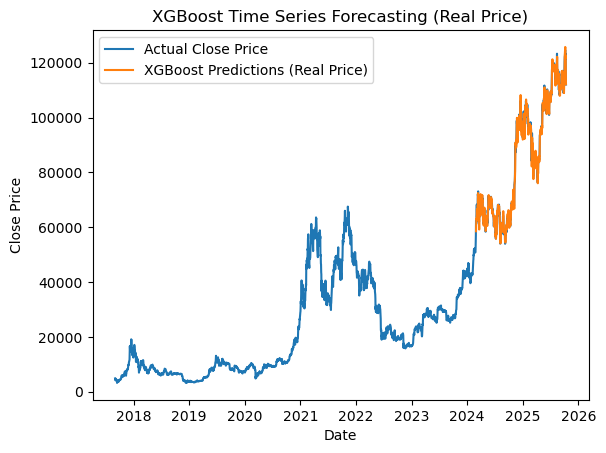

In [79]:
real_price_predictions = test_data['Close'].shift(1) + xgb_predictions_diff
plt.plot(data_daily.index, data_daily["Close"], label='Actual Close Price')
plt.plot(test_data.index, real_price_predictions, label='XGBoost Predictions (Real Price)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('XGBoost Time Series Forecasting (Real Price)')
plt.legend()
plt.show()

* the  model performed better after applying differncing at training it on stationary data and testing it on the data before diff

## Task 7: Multi-Step Forecasting (Direct Strategy)
As discussed in Lecture 3, predicting multiple steps into the future (e.g., 3 days ahead) requires specific strategies to avoid compounding errors.

Implement the **Direct Strategy** for a 3-day ahead forecast:
1. Create a new target variable in your original dataframe: `target_lead_3` (The Close price shifted *backwards* by 3 days using `.shift(-3)`).
2. Drop the newly created NaNs.
3. Set up a new Train/Test split.
4. Train a completely separate, independent model to predict `target_lead_3` directly from today's features.

In [80]:
# YOUR CODE HERE
data_daily.head()

,Close,Volume,day_of_week,month,year,is_weekend,lag_1,lag_3,lag_7,roll_mean_7,roll_std_7,Close_diff,diff_lag_1,diff_lag_3,diff_lag_7,diff_roll_mean_7,diff_roll_std_7
timestamp,,,,,,,,,,,,,,,,,
2017-09-01,4834.91,560.666366,4,9,2017,0,4724.89,4587.48,4280.68,4533.794286,200.333108,110.02,169.75,200.79,-35.33,79.175714,89.679365
2017-09-02,4472.14,929.148595,5,9,2017,1,4834.91,4555.14,4337.44,4553.037143,184.144127,-362.77,110.02,-32.34,56.76,19.242857,190.579926
2017-09-03,4509.08,691.216198,6,9,2017,1,4472.14,4724.89,4310.01,4581.475714,153.113862,36.94,-362.77,169.75,-27.43,28.438571,189.502487
2017-09-04,4100.11,1394.644614,0,9,2017,0,4509.08,4834.91,4386.69,4540.535714,231.913065,-408.97,36.94,110.02,76.68,-40.940000,248.586831
2017-09-05,4366.47,1228.938157,1,9,2017,0,4100.11,4472.14,4587.48,4508.962857,239.380871,266.36,-408.97,-362.77,200.79,-31.572857,260.178839


In [81]:
data_daily["target_lead_3"] = data_daily["Close"].shift(-3)
data_daily.dropna(inplace=True)
train_size = int(len(data_daily) * 0.8)
train_direct = data_daily.iloc[:train_size]
test_direct = data_daily.iloc[train_size:]

features_direct = [col for col in data_daily.columns if col not in ['Close', 'target_lead_3', 'Close_diff']]
target_direct = 'target_lead_3'

model_direct_3d = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='rmse'
)

model_direct_3d.fit(train_direct[features_direct], train_direct[target_direct],
                    eval_set=[(train_direct[features_direct], train_direct[target_direct]),
							 (test_direct[features_direct], test_direct[target_direct])],
				   verbose=False)
preds_direct = model_direct_3d.predict(test_direct[features_direct])
rmse_direct = root_mean_squared_error(test_direct[target_direct], preds_direct)

print(f"3 day lead RMSE: {rmse_direct:.2f}")

3 day lead RMSE: 34117.77


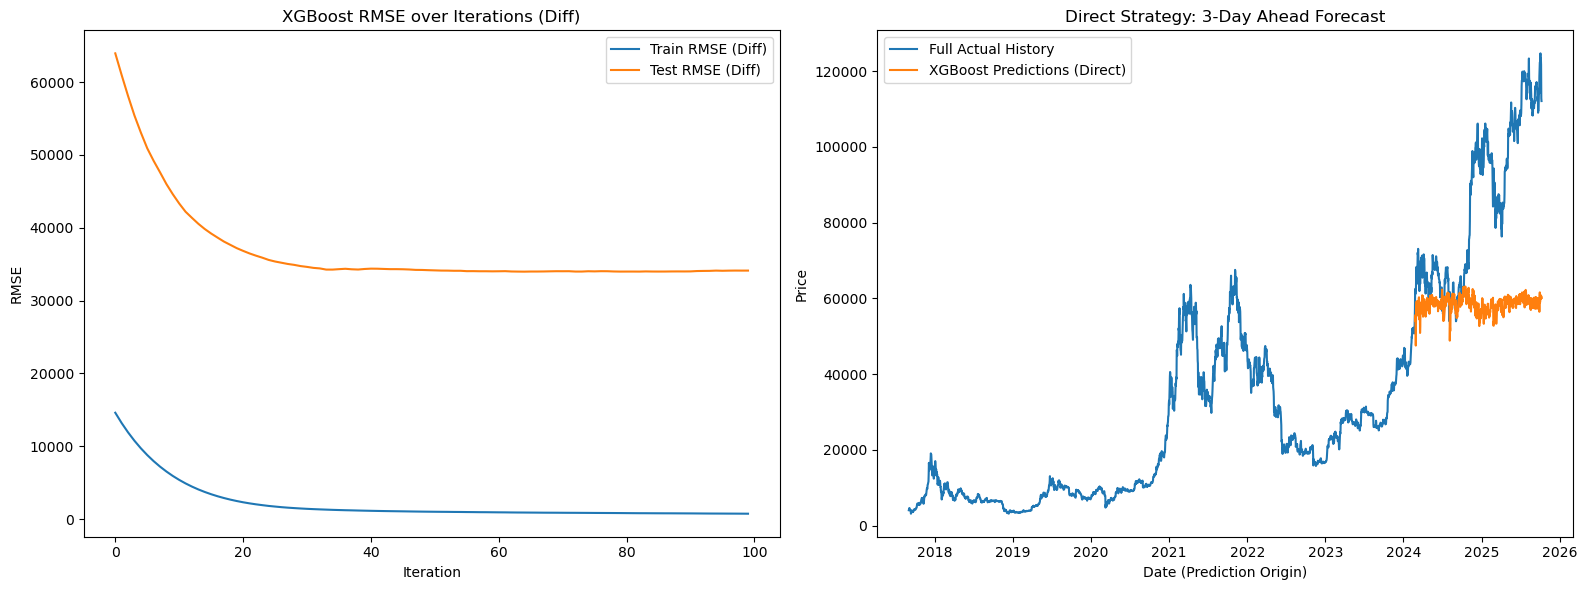

In [82]:
results_diff_3 = model_direct_3d.evals_result()
train_rmse = results_diff_3['validation_0']['rmse']
test_rmse = results_diff_3['validation_1']['rmse']
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].plot(train_rmse, label='Train RMSE (Diff)')
ax[0].plot(test_rmse, label='Test RMSE (Diff)')
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('RMSE')
ax[0].set_title('XGBoost RMSE over Iterations (Diff)')
ax[0].legend()

ax[1].plot(data_daily.index, data_daily["target_lead_3"], label='Full Actual History')
ax[1].plot(test_direct.index, preds_direct, label='XGBoost Predictions (Direct)')
ax[1].set_title('Direct Strategy: 3-Day Ahead Forecast')
ax[1].set_xlabel('Date (Prediction Origin)')
ax[1].set_ylabel('Price')
ax[1].legend()

plt.tight_layout()
plt.show()